In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [15]:
import pandas as pd

df = pd.read_excel("AAPL_Stock_Data.xlsx")

df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [16]:
df.shape

(9909, 7)

The dataset contains 9909 rows and 7 columns.

In [17]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='str')

The dataset contains stock price information including Open, High, Low, Close, Adjusted Close, and Trading Volume.

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       9909 non-null   datetime64[us]
 1   Open       9909 non-null   float64       
 2   High       9909 non-null   float64       
 3   Low        9909 non-null   float64       
 4   Close      9909 non-null   float64       
 5   Adj Close  9909 non-null   float64       
 6   Volume     9909 non-null   int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 542.0 KB


Look for:

Number of entries
Missing values
Data types

In [19]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Observation:
No missing values were found in the dataset.

In [20]:
df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume
count,9909,9909.000000,9909.000000,9909.000000,9909.000000,9909.000000,9.909000e+03
mean,2000-07-30 08:33:08.010899,32.606849,32.936079,32.277560,32.618030,30.576570,8.582916e+07
min,1980-12-12 00:00:00,0.198661,0.198661,0.196429,0.196429,0.155638,3.472000e+05
25%,1990-10-02 00:00:00,1.071429,1.089286,1.048571,1.071429,0.917643,3.304230e+07
50%,2000-07-21 00:00:00,1.729286,1.758929,1.696429,1.732143,1.466154,5.766490e+07
75%,2010-05-28 00:00:00,35.799999,36.265713,35.328571,35.761429,31.042374,1.069992e+08
max,2020-04-01 00:00:00,324.739990,327.850006,323.350006,327.200012,327.200012,1.855410e+09
std,NaN,58.415759,59.001576,57.883037,58.471899,56.746275,8.597195e+07


This is one of the most important EDA commands.

Pay attention to:

Average Close Price
Highest Close Price
Lowest Close Price
Volume statistics

In [21]:
close_prices = df["Close"].to_numpy()

print("Average Close Price:", np.mean(close_prices))
print("Highest Close Price:", np.max(close_prices))
print("Lowest Close Price:", np.min(close_prices))
print("Median Close Price:", np.median(close_prices))
print("Standard Deviation:", np.std(close_prices))

Average Close Price: 32.61803014989823
Highest Close Price: 327.200012207031
Lowest Close Price: 0.196428567171096
Median Close Price: 1.73214280605316
Standard Deviation: 58.468948776661556


NumPy analysis shows the average, median, and spread of Apple's closing stock prices over the observed period.

In [22]:
df["Date"] = pd.to_datetime(df["Date"])

In [23]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())

Start Date: 1980-12-12 00:00:00
End Date: 2020-04-01 00:00:00


The dataset covers multiple decades of Apple stock market history.

In [24]:
df["Daily_Return"] = df["Close"].pct_change()

In [25]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400,NaN
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,-0.052174
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,-0.073394
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,0.024752
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,0.028986


df.head()

You should see a new column named:

Daily_Return

In [26]:
print("Average Return:", df["Daily_Return"].mean())
print("Best Return:", df["Daily_Return"].max())
print("Worst Return:", df["Daily_Return"].min())

Average Return: 0.001041334236172605
Best Return: 0.3322784850238667
Worst Return: -0.518691580038798


These values measure stock performance volatility.

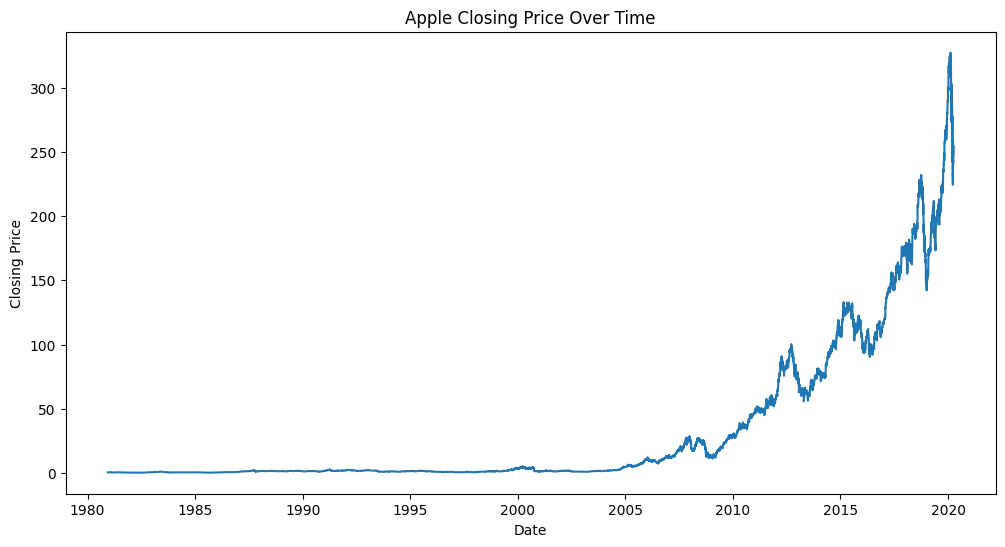

In [27]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"])

plt.title("Apple Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

This chart is usually the first visualization in financial EDA.

In [28]:
df["MA20"] = df["Close"].rolling(window=20).mean()

A moving average smooths daily fluctuations.

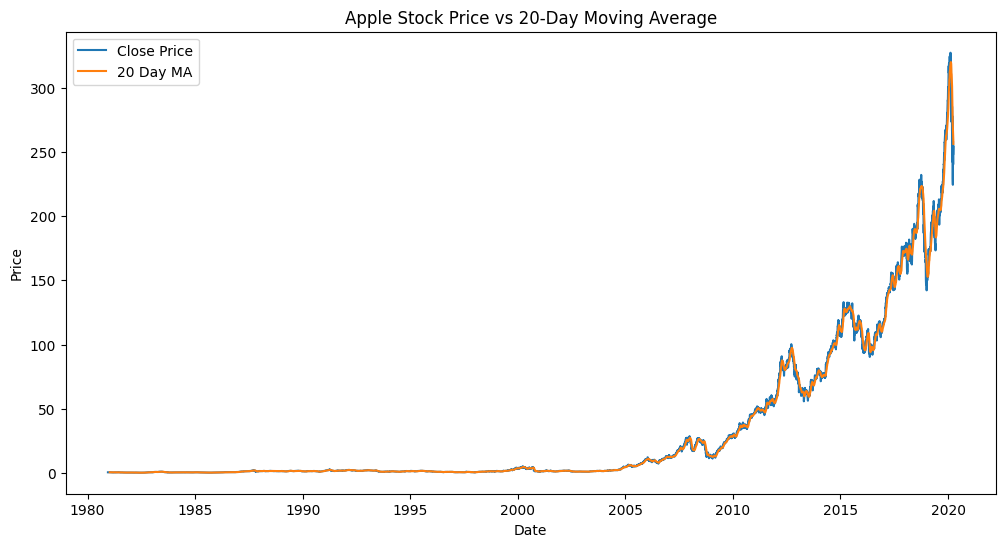

In [29]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"], label="Close Price")

plt.plot(df["Date"], df["MA20"], label="20 Day MA")

plt.title("Apple Stock Price vs 20-Day Moving Average")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

In [30]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,MA20
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400,NaN,NaN
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,-0.052174,NaN
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,-0.073394,NaN
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,0.024752,NaN
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,0.028986,NaN


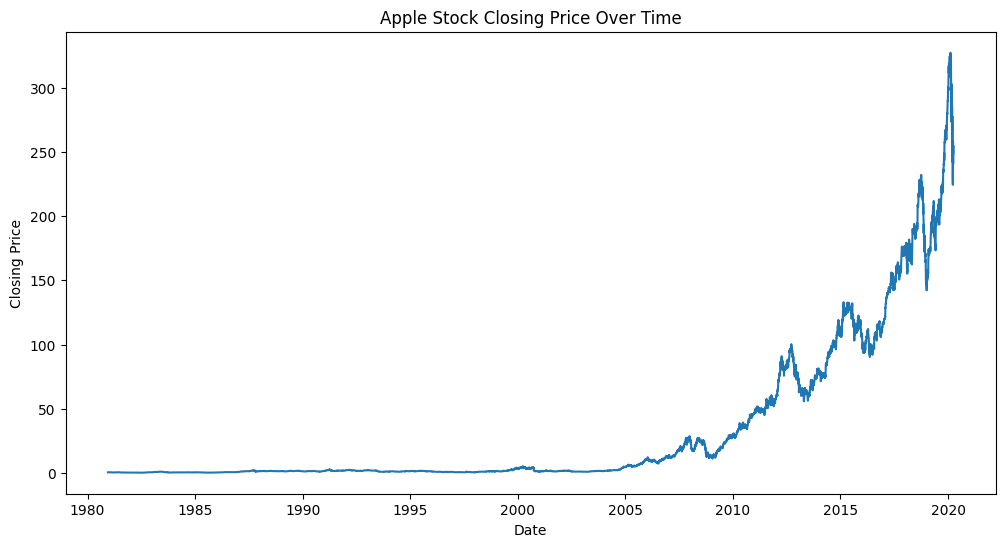

In [31]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"])

plt.title("Apple Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

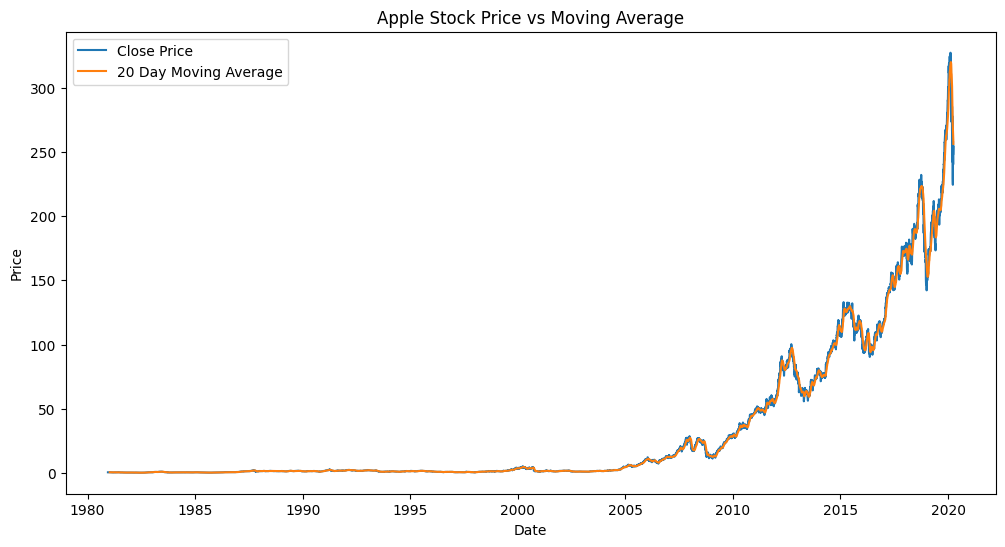

In [32]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"], label="Close Price")

plt.plot(df["Date"], df["MA20"], label="20 Day Moving Average")

plt.title("Apple Stock Price vs Moving Average")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.show()

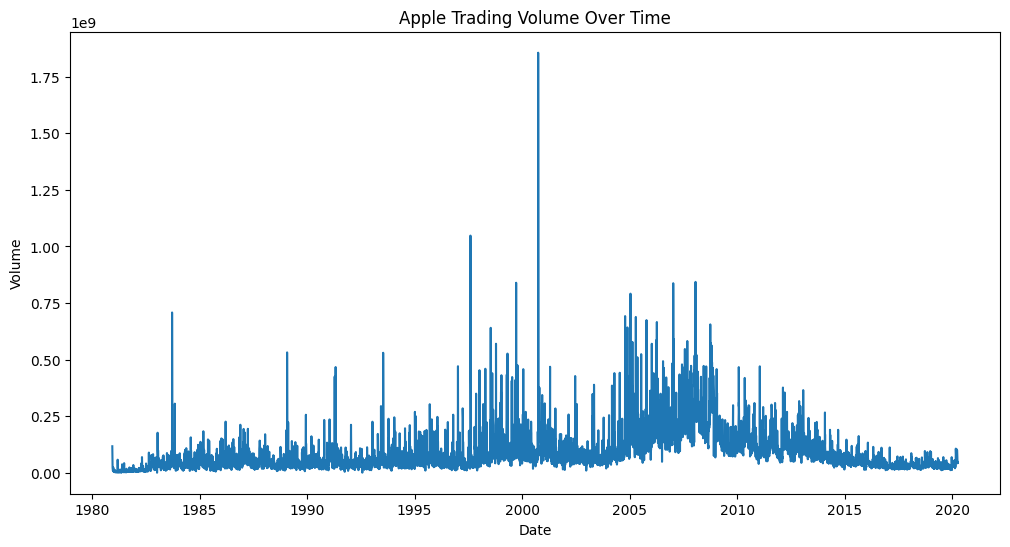

In [33]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Volume"])

plt.title("Apple Trading Volume Over Time")

plt.xlabel("Date")
plt.ylabel("Volume")

plt.show()

In [34]:
print("Best Daily Return:")
print(df["Daily_Return"].max())

print("\nWorst Daily Return:")
print(df["Daily_Return"].min())

Best Daily Return:
0.3322784850238667

Worst Daily Return:
-0.518691580038798


In [35]:
df.loc[df["Close"].idxmax()]

Date            2020-02-12 00:00:00
Open                     321.470001
High                     327.220001
Low                      321.470001
Close                    327.200012
Adj Close                327.200012
Volume                     28432600
Daily_Return               0.023748
MA20                     318.202002
Name: 9874, dtype: object

In [36]:
df.loc[df["Close"].idxmin()]

Date            1982-07-08 00:00:00
Open                       0.198661
High                       0.198661
Low                        0.196429
Close                      0.196429
Adj Close                  0.155638
Volume                     41081600
Daily_Return              -0.043478
MA20                       0.229129
Name: 394, dtype: object

# Key Findings

1. The dataset contains historical Apple stock data spanning several decades.

2. Apple demonstrated significant long-term growth in stock price.

3. Daily returns indicate periods of both growth and volatility.

4. Trading volume varied significantly across different periods.

5. The 20-day moving average helped smooth short-term fluctuations and reveal broader trends.

6. Apple's highest closing price reflects strong long-term shareholder value creation.

7. Historical data suggests Apple has been one of the strongest long-term performers in the equity market.